In [5]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as scip

POSITION OF A STAR

Part1

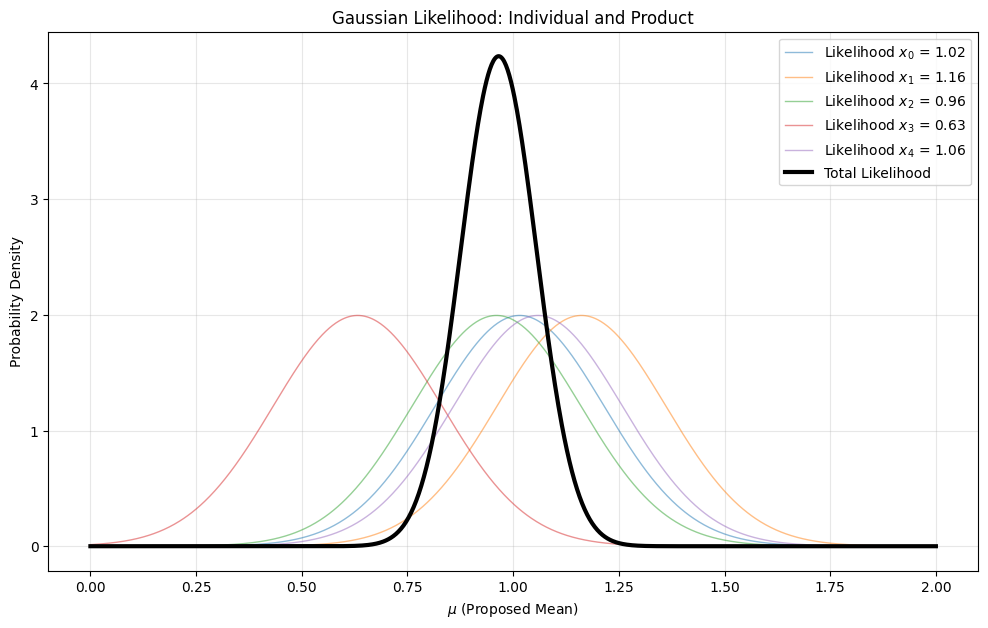

Mean with MLE: 0.96496
Analytical Mean: 0.96567


In [ ]:
mu_true = 1
sigma = 0.2
n_samples = 5

# Generate n_sample gaussian data
gaussian_data = scip.stats.norm.rvs(loc=mu_true, scale=sigma, size=n_samples)

#Possible value of \mu from MLE
mu_proposed = np.linspace(0, 2.0, 1000)

plt.figure(figsize=(12, 7))

total_likelihood = np.ones_like(mu_proposed) 

#Plot individual likelihoods
for i, x_i in enumerate(gaussian_data):

    individual_likelihood = scip.stats.norm.pdf(x_i, loc=mu_proposed, scale=sigma)
    total_likelihood *= individual_likelihood
    
    plt.plot(mu_proposed, individual_likelihood, alpha=0.5, lw=1, 
             label=f'Likelihood $x_{i}$ = {x_i:.2f}')

# Plot Likelihood of the whole dataset
plt.plot(mu_proposed, total_likelihood, color='black', lw=3, label='Total Likelihood')

# Find the MLE solution using np.argmax
mle_grid_idx = np.argmax(total_likelihood)
mu_mle_grid = mu_proposed[mle_grid_idx]

# Calculate the Analytical MLE (It is the Arithmetic Mean for homoscedastic Gaussian)
mu_analytical = np.mean(gaussian_data)

# Plot
plt.title("Gaussian Likelihood: Individual and Product")
plt.xlabel("$\mu$ (Proposed Mean)")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Mean with MLE: {mu_mle_grid:.5f}")
print(f"Analytical Mean: {mu_analytical:.5f}")

Part 2

Mean with MLE: 0.9650
Fisher Error Estimate: 0.0894


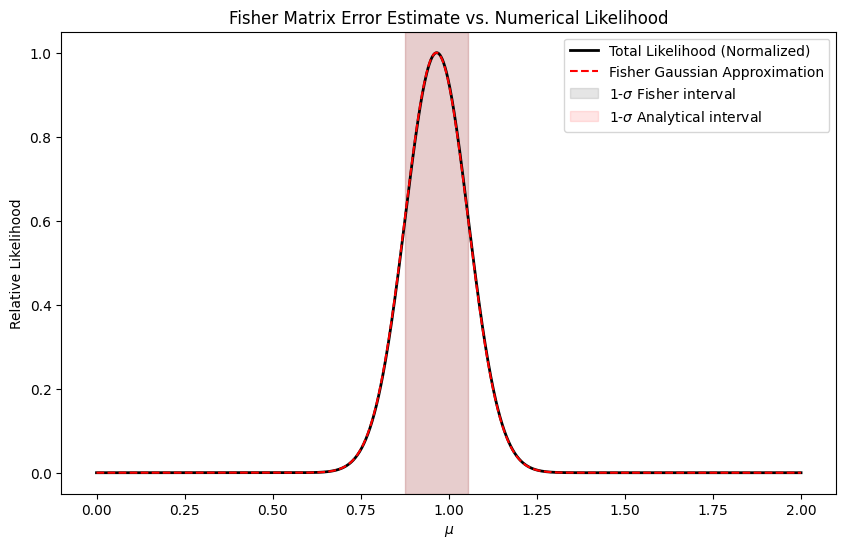

$\mu$ error with Fisher method: 0.08944
$\mu$ error analytical:  0.08944


In [25]:
#initially I tried a for loop to calculate the derivatives, but to make it more efficient, I switched to np.diff


from matplotlib.cbook import ls_mapper


log_L = np.log(total_likelihood)

# Numerical differentiation using np.diff
# delta_mu is the spacing of the grid (mu_proposed), which is constant in my case.
d_mu = mu_proposed[1] - mu_proposed[0]

# First derivative:
# np.diff returns an array of size N-1
first_deriv = np.diff(log_L) / d_mu

# Second derivative:
# This returns an array of size N-2
second_deriv = np.diff(first_deriv) / d_mu

# We find the index of the maximum likelihood 
mle_idx = np.argmax(log_L)

# Since second_deriv is of size N-2, and the MLE index corresponds to the original mu_proposed array, we need to adjust the index for second_deriv.
fisher_info_value = second_deriv[mle_idx - 1]

# Calculate the uncertainty sigma_mu = sqrt(-1 / second_derivative) at the MLE point
mu_error_fisher = np.sqrt(-1.0 / fisher_info_value)

# Analytical value of \sigma_\mu
mu_error_analytical = sigma/np.sqrt(n_samples)

print(f"Mean with MLE: {mu_proposed[mle_idx]:.4f}")
print(f"Fisher Error Estimate: {mu_error_fisher:.4f}")

# Plotting to compare
plt.figure(figsize=(10, 6))

# Plot numerical likelihood (normalized to peak at 1 for comparison)
plt.plot(mu_proposed, total_likelihood / np.max(total_likelihood), 
         label='Total Likelihood (Normalized)', color='black', lw=2)

# Plot a Gaussian centered at the max of likelihood and with scale = Fisher Error
fisher_gaussian = scip.stats.norm.pdf(mu_proposed, loc=mu_proposed[mle_idx], scale=mu_error_fisher)

plt.plot(mu_proposed, fisher_gaussian / np.max(fisher_gaussian), 
         label='Fisher Gaussian Approximation', ls='--', color='red')

plt.axvspan(mu_proposed[mle_idx] - mu_error_fisher, 
            mu_proposed[mle_idx] + mu_error_fisher, 
            alpha=0.1, color='black', label='1-$\sigma$ Fisher interval')

plt.axvspan(mu_analytical - mu_error_analytical, mu_analytical + mu_error_analytical,
            alpha=0.1, color='red', label='1-$\sigma$ Analytical interval')

plt.title("Fisher Matrix Error Estimate vs. Numerical Likelihood")
plt.xlabel("$\mu$")
plt.ylabel("Relative Likelihood")
plt.legend()
plt.show()

print (f"$\mu$ error with Fisher method: {mu_error_fisher:.5f}")
print (f"$\mu$ error analytical:  {mu_error_analytical:.5f}")
